# Adapted from this [notebook](/home/links/ct715/eddy_feedback/reproduce/saffin_2024/saffin.ipynb)

In [6]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import os

import functions.eddy_feedback as ef 
import functions.data_wrangling as dw

In [7]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'
data_6h = os.path.join(path, '6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
data_daily = os.path.join(path, 'daily_ubar_epf-pr-QG_1MS_1958-2016.nc')

# import dataset for maths servers
ds_6h = xr.open_dataset(data_6h)
ds_day = xr.open_dataset(data_daily)

ds = {'6h': ds_6h, 'daily': ds_day}

ds_djf, ds_jas = {}, {}
for dataset in ds.keys():
    ds_djf[dataset] = dw.seasonal_mean(ds[dataset], season='djf')
    print(ds_djf[dataset].dims)
    ds_jas[dataset] = dw.seasonal_mean(ds[dataset], season='jas')
    print(ds_jas[dataset].dims)


Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 58, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 59, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 58, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 59, 'level': 37, 'lat': 73})


# Daily vs 6-hourly comparison (Not really a difference)

### Zonal-mean zonal wind (DJF)

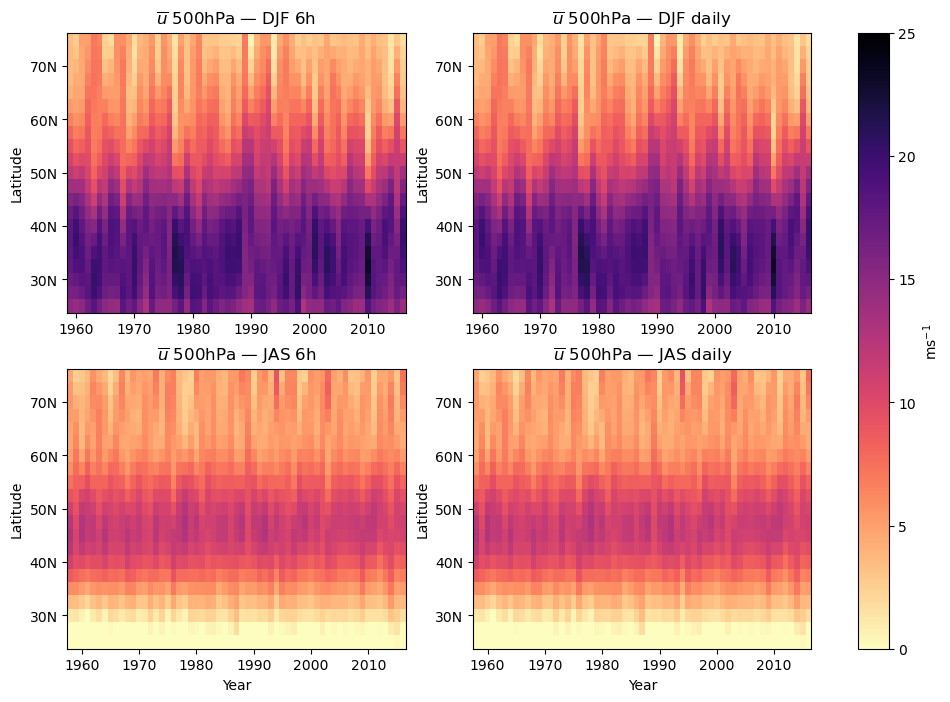

In [8]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        u = ds_res.ubar.sel(level=500.)
        u = u.where(ds_res.lat >= 25., drop=True)
        u = u.where(ds_res.lat <= 75., drop=True)
        u = u.transpose()

        im = u.plot(ax=ax, cmap='magma_r', vmin=0, vmax=25,
                    add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\overline{{u}}$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='ms$^{-1}$', ticks=[0, 5, 10, 15, 20, 25])
plt.show()

### DivFy (primitive)

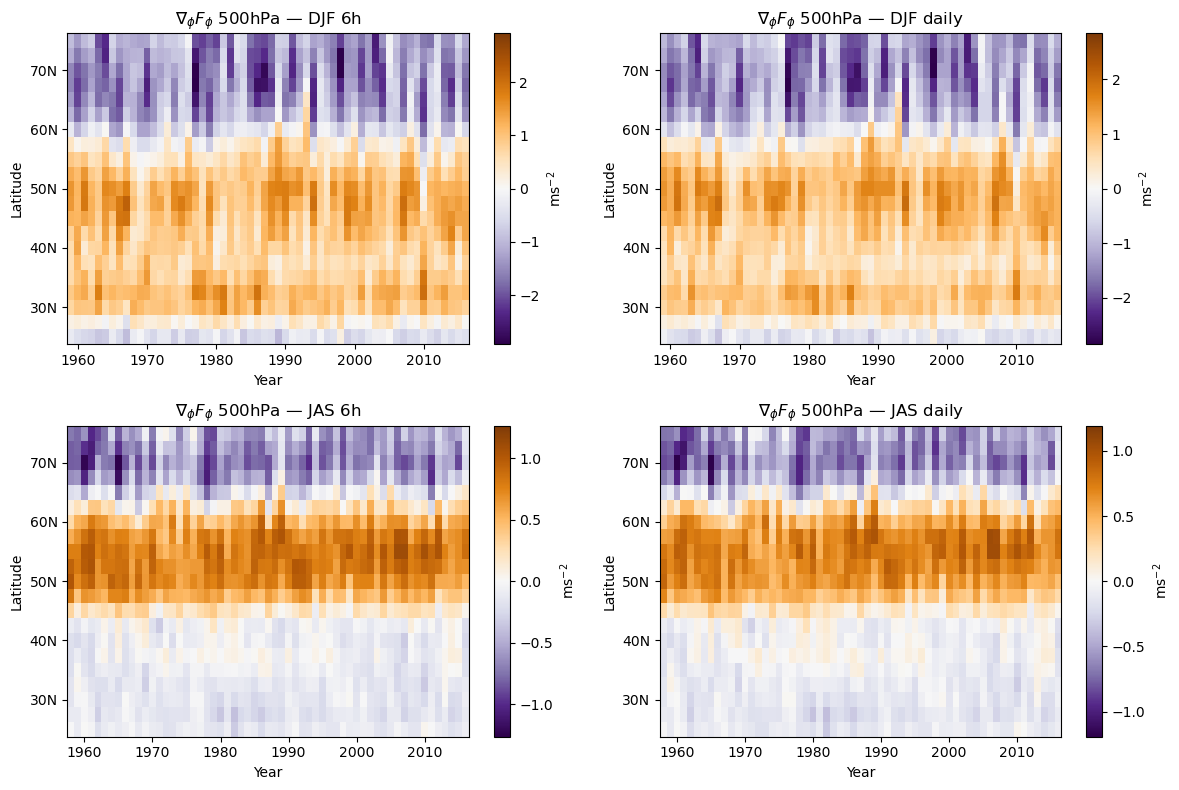

In [9]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        div1 = ds_res.div1_pr.sel(level=500.)
        div1 = div1.where(ds_res.lat >= 25., drop=True)
        div1 = div1.where(ds_res.lat <= 75., drop=True)
        div1 = div1.transpose()

        div1.plot(ax=ax, cmap='PuOr_r',# vmin=-3.5e-5, vmax=3.5e-5,
                  cbar_kwargs={'label': 'ms$^{-2}$'})
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (QG)

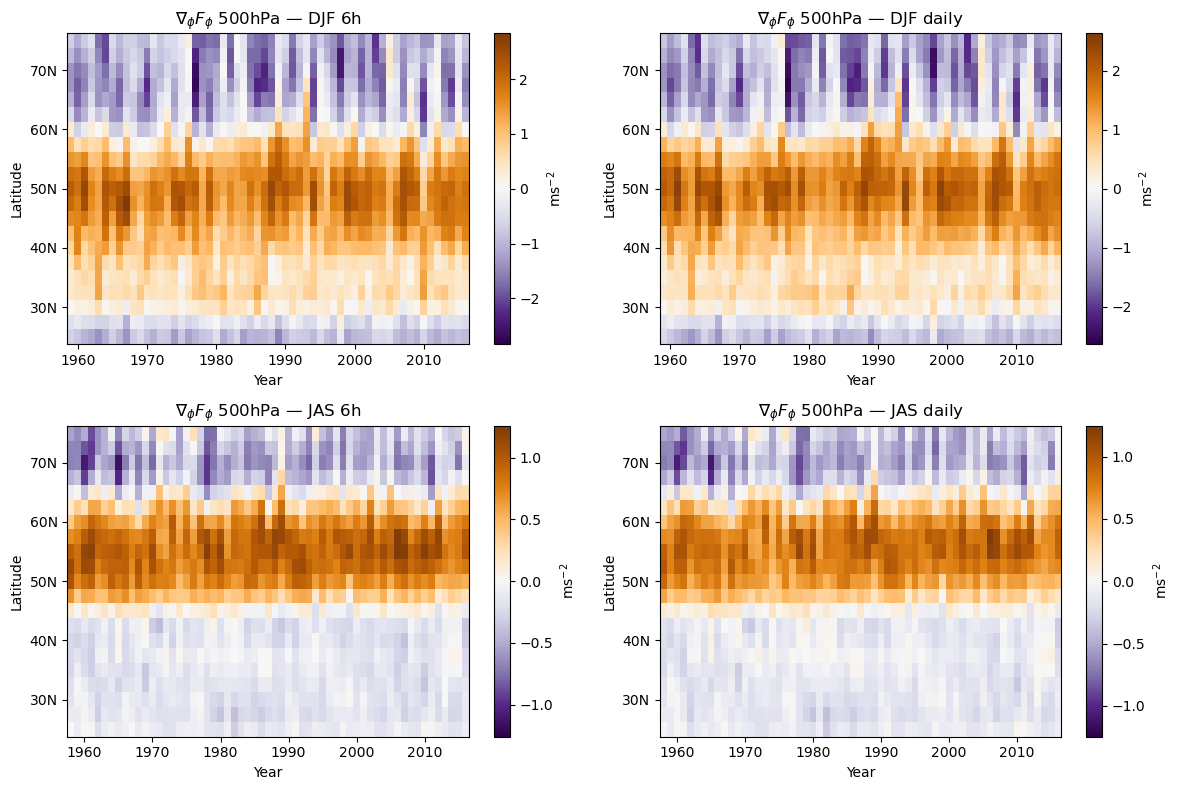

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        div1 = ds_res.div1_QG.sel(level=500.)
        div1 = div1.where(ds_res.lat >= 25., drop=True)
        div1 = div1.where(ds_res.lat <= 75., drop=True)
        div1 = div1.transpose()

        div1.plot(ax=ax, cmap='PuOr_r',# vmin=-3.5e-5, vmax=3.5e-5,
                  cbar_kwargs={'label': 'ms$^{-2}$'})
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

# Covariance

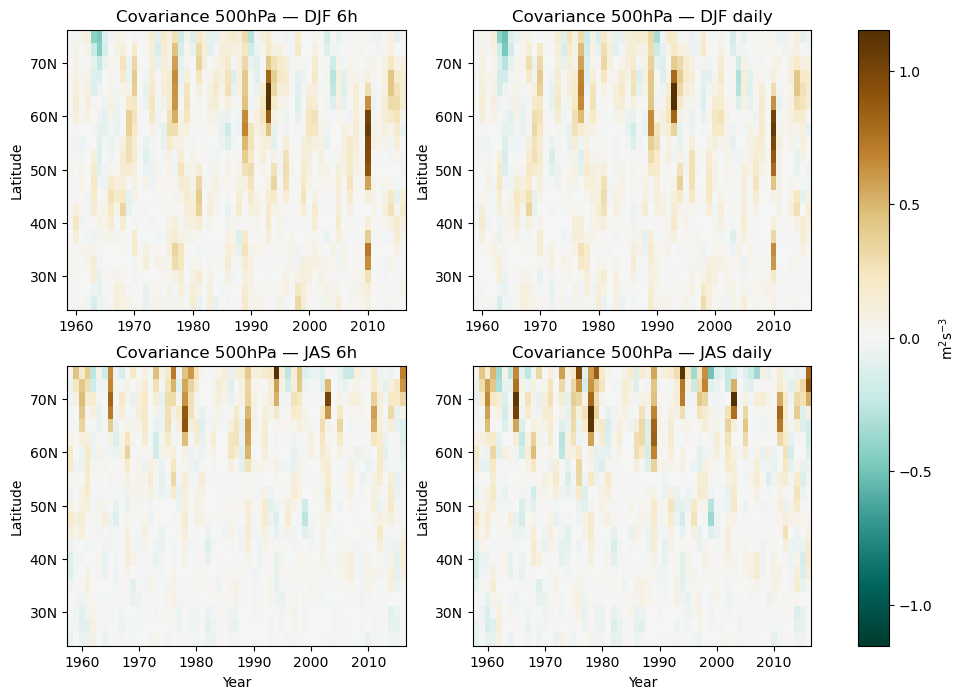

In [11]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        u    = ds_res.ubar.sel(level=500.)
        div1 = ds_res.div1_pr.sel(level=500.)

        u    = u.where(ds_res.lat >= 25., drop=True).where(ds_res.lat <= 75., drop=True)
        div1 = div1.where(ds_res.lat >= 25., drop=True).where(ds_res.lat <= 75., drop=True)

        uanom    = u - u.mean('time')
        div1anom = div1 - div1.mean('time')
        prod = (uanom * div1anom).transpose()

        im = prod.plot(ax=ax, cmap='BrBG_r', add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'Covariance 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='m$^2$s$^{-3}$')
plt.show()

# Correlation

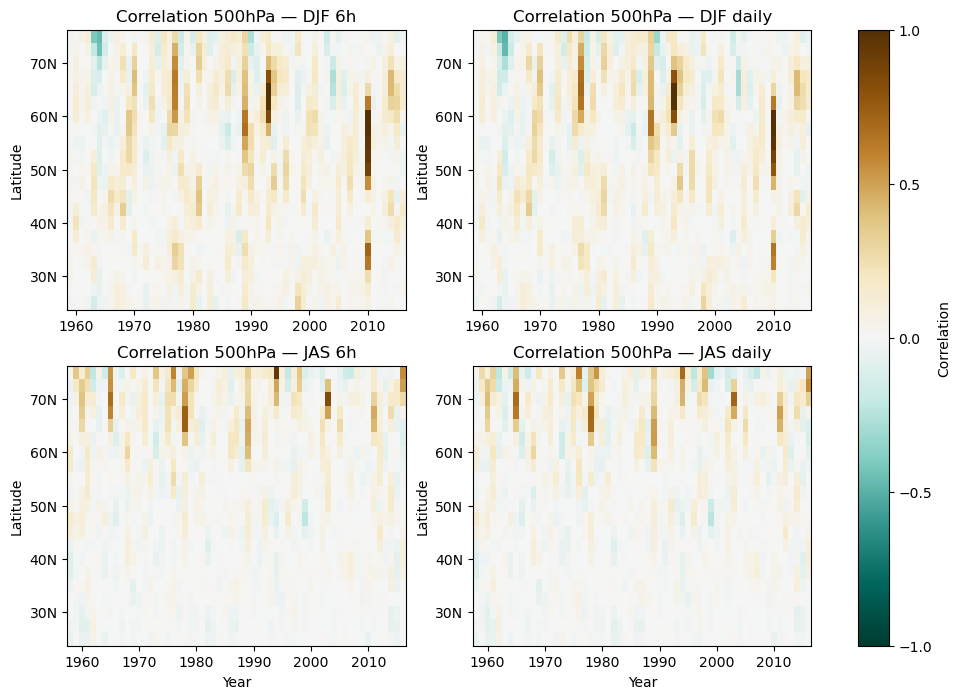

In [14]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        u    = ds_res.ubar.sel(level=500.)
        div1 = ds_res.div1_pr.sel(level=500.)

        u    = u.where(ds_res.lat >= 25., drop=True).where(ds_res.lat <= 75., drop=True)
        div1 = div1.where(ds_res.lat >= 25., drop=True).where(ds_res.lat <= 75., drop=True)

        uanom    = u - u.mean('time')
        div1anom = div1 - div1.mean('time')
        prod = uanom * div1anom

        corr = prod / (u.std() * div1.std())
        corr = corr.transpose()

        im = corr.plot(ax=ax, cmap='BrBG_r', vmin=-1., vmax=1.,
                       add_colorbar=False)
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'Correlation 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im, ax=axes, label='Correlation', ticks=[-1, -0.5, 0, 0.5, 1])
plt.show()